# Bilinear vs bicubic resize (96→224) — visual comparison

Temporary notebook: load 3 PCam patches, upscale each with **bilinear** and **bicubic**, then show them side by side so you can see the difference.

In [2]:
import os
import sys
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

PROJECT_ROOT = os.path.abspath(os.path.join(os.getcwd(), ".."))
if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)
sys.path.insert(0, os.path.join(PROJECT_ROOT, "pcam-master"))

DATA_DIR = os.path.join(PROJECT_ROOT, "pcam_data")
from keras_pcam.dataset.pcam import load_data

(train_x, train_y, _), _, _ = load_data(data_dir=DATA_DIR)

# Pick 3 patches (different indices for variety)
indices = [0, 5000, 15000]
patches = []
for i in indices:
    p = np.asarray(train_x[i])
    if p.max() <= 1.0:
        p = (np.clip(p, 0, 1) * 255).astype(np.uint8)
    patches.append(p)

print(f"Loaded {len(patches)} patches, shape {patches[0].shape}")


Loaded 3 patches, shape (96, 96, 3)


In [3]:
def resize_bilinear(rgb_96):
    """96x96 RGB uint8 -> 224x224 via PIL bilinear."""
    img = Image.fromarray(rgb_96)
    return np.array(img.resize((224, 224), Image.BILINEAR))

def resize_bicubic(rgb_96):
    """96x96 RGB uint8 -> 224x224 via PIL bicubic."""
    img = Image.fromarray(rgb_96)
    return np.array(img.resize((224, 224), Image.BICUBIC))

bilinear_224 = [resize_bilinear(p) for p in patches]
bicubic_224 = [resize_bicubic(p) for p in patches]
print("Resized to 224×224 (bilinear and bicubic).")


Resized to 224×224 (bilinear and bicubic).


In [ ]:
# Quick timing: bilinear vs bicubic (96→224) per image
import time
n_repeat = 2000
p = patches[0]

t0 = time.perf_counter()
for _ in range(n_repeat):
    img = Image.fromarray(p)
    _ = np.array(img.resize((224, 224), Image.BILINEAR))
t_bilinear = time.perf_counter() - t0

t0 = time.perf_counter()
for _ in range(n_repeat):
    img = Image.fromarray(p)
    _ = np.array(img.resize((224, 224), Image.BICUBIC))
t_bicubic = time.perf_counter() - t0

ms_bilinear = 1000 * t_bilinear / n_repeat
ms_bicubic = 1000 * t_bicubic / n_repeat
ratio = t_bicubic / t_bilinear
n_train = 262_144
print(f"Per image (96→224):  bilinear {ms_bilinear:.3f} ms   bicubic {ms_bicubic:.3f} ms")
print(f"Bicubic is ~{ratio:.2f}x slower than bilinear.")
print(f"Full train set ({n_train:,} images): bilinear ~{t_bilinear/n_repeat*n_train/60:.1f} min   bicubic ~{t_bicubic/n_repeat*n_train/60:.1f} min")

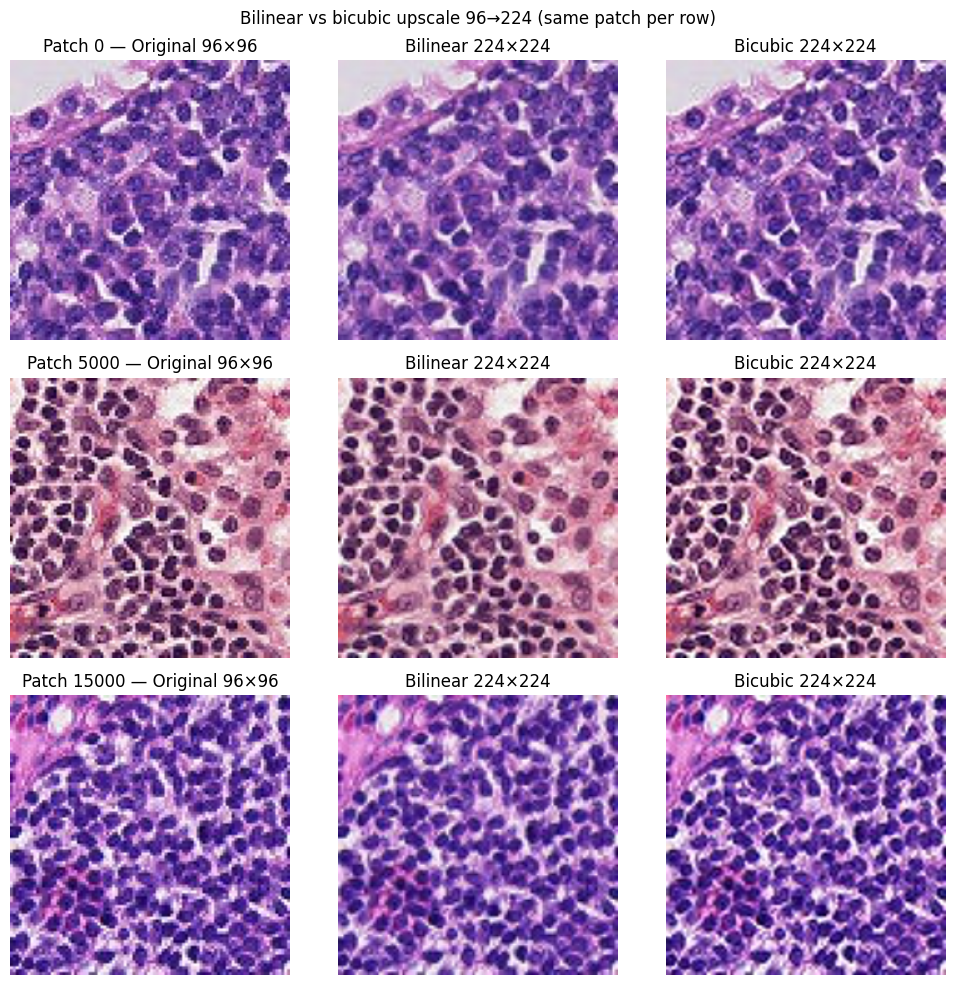

In [4]:
fig, axes = plt.subplots(3, 3, figsize=(10, 10))

for row, (orig, bl, bc) in enumerate(zip(patches, bilinear_224, bicubic_224)):
    axes[row, 0].imshow(orig)
    axes[row, 0].set_title(f"Patch {indices[row]} — Original 96×96")
    axes[row, 0].axis("off")
    axes[row, 1].imshow(bl)
    axes[row, 1].set_title(f"Bilinear 224×224")
    axes[row, 1].axis("off")
    axes[row, 2].imshow(bc)
    axes[row, 2].set_title(f"Bicubic 224×224")
    axes[row, 2].axis("off")

plt.suptitle("Bilinear vs bicubic upscale 96→224 (same patch per row)", fontsize=12)
plt.tight_layout()
plt.show()


**What to look for:** Bicubic often keeps edges and fine structures slightly sharper; bilinear can look a bit softer. Differences are subtle at this scale—check nuclei and tissue boundaries.